# EDA For The DataSets

Exploration Data Analysis will now be done on:

Sales Combined DataSet: Sales_Combined_Dataset_Visualization.csv

As this a combination of the other 3 csv files no need to test the others

In [2]:
#import libraries
import os
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

#added by me for visualisation fine tuning
from matplotlib.ticker import MultipleLocator

#added by me for plotly.express visualisation issue
import nbformat 


#below solution provided by chatGPT 
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root / "assets" / "python_files") not in sys.path:
    sys.path.insert(0, str(project_root / "assets" / "python_files"))
    
import modGlobal
import modETL_Library as modETL
#end solution provided by chatGPT

# Section 1 - Initalisation

## Intitialise All Variables To Be Used In Global Stack 


In [3]:
#DataFrame variables for EDA
dfSales_Combined_DataSet = None

#stores current directory
strCurrentDir = ""

#other vars
intMissingPercent = 0
intMissing = 0
dictDataFrames = dict()


## Set Current Directory To Base Project Directory


In [4]:
#get project directory - default is jupyter notebook sub folder as that is where this file is located!
#so move back one to the project root path
# Source - https://stackoverflow.com/a/17726833
# Posted by chimpsarehungry
# Retrieved 2026-07-05, License - CC BY-SA 3.0

#get current folder
strCurrentDir = os.getcwd()

#is the last part of the path the project directory?
if not strCurrentDir.endswith(modGlobal.CNST_STR_PROJECT_DIR):
   #get current working directory and move back one to the project root path
   strCurrentDir =  os.path.normpath(os.getcwd() + os.sep + os.pardir)
   os.chdir(os.path.dirname(strCurrentDir))
   #change directory
   os.chdir(strCurrentDir)

#confirm current directory is project directory
print(f"Current Directory: \n {os.getcwd()}")

Current Directory: 
 /Users/rogerwilliams/Projects/Python/CourseProjects/Project2-SalesAnalysis


# Section 2

- Read csv file
- Look at skew, kurtosis and Q-Q plots for ALL columns

Why all columns?

There might be extra insights to be gained by what would normally be a folly as some columns such as Store have
no effect on correlation or variance *individually* but as a data analysist we need to be thorough!



In [5]:
#read file from working files folder
#ETL library returns a dictionary of all files in the folder with the attribute name
#set to the actual csv filename
dictDataFrames = modETL.funcReadVisualisationFilesReturnDictionary()
dfSales_Combined_DataSet_Work = dictDataFrames["Sales_Combined_DataSet_Visualisation.csv"]

4 csv Files Read Into DataFrames

DataFrames Created:
Sales_Combined_DataSet_Visualisation.csv
Features_DataSet_Visualisation.csv
Sales_DataSet_Visualisation.csv
Stores_DataSet_Visualisation.csv




# Get Column Skew

DataFrame Skew Values Per Column:
Unnamed: 0           Skew: 0.00 - Approximately Symmetrical Kurtosis: -1.20
Store                Skew: 0.08 - Approximately Symmetrical Kurtosis: -1.15
Dept                 Skew: 0.36 - Approximately Symmetrical Kurtosis: -1.22
Weekly_Sales         Skew: 3.26 - Highly Positively Skewed Kurtosis: 21.49
IsHoliday            Skew: 3.36 - Highly Positively Skewed Kurtosis: 9.29
MarkDown1            Skew: 4.73 - Highly Positively Skewed Kurtosis: 34.92
MarkDown2            Skew: 10.65 - Highly Positively Skewed Kurtosis: 145.42
MarkDown3            Skew: 14.92 - Highly Positively Skewed Kurtosis: 248.10
MarkDown4            Skew: 8.08 - Highly Positively Skewed Kurtosis: 86.24
MarkDown5            Skew: 9.96 - Highly Positively Skewed Kurtosis: 183.41
Store_Type           Skew: 0.69 - Approximately Symmetrical Kurtosis: -0.60
Store_Size           Skew: -0.33 - Highly Negatively Skewed Kurtosis: -1.21
Temperature          Skew: -0.32 - Highly Negatively Skew

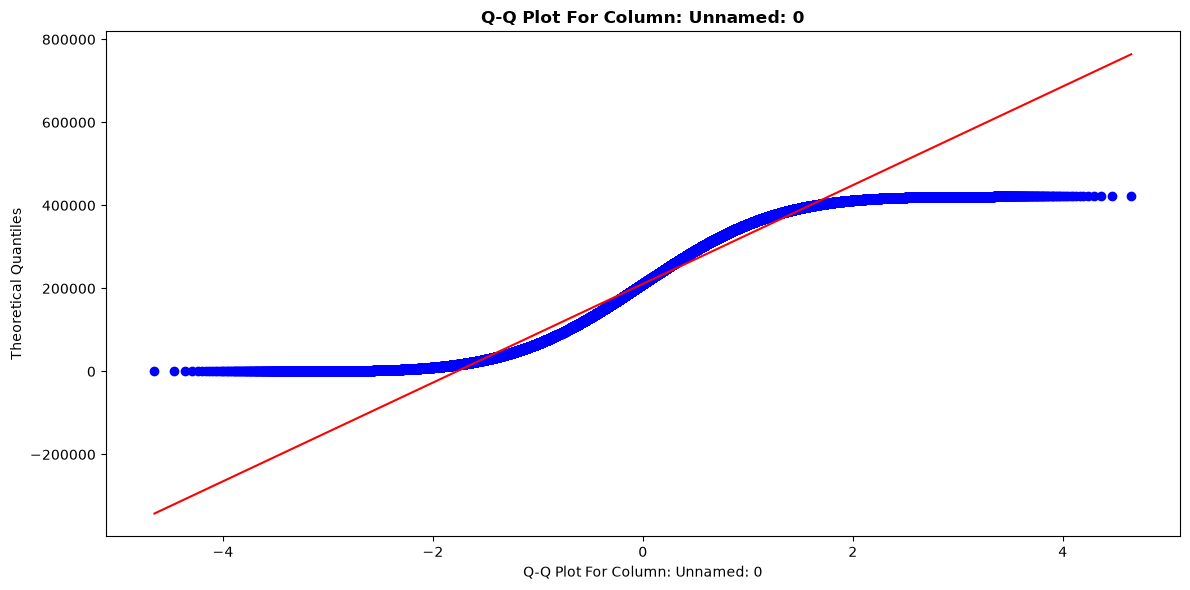



Q-Q Plot For Column: Store


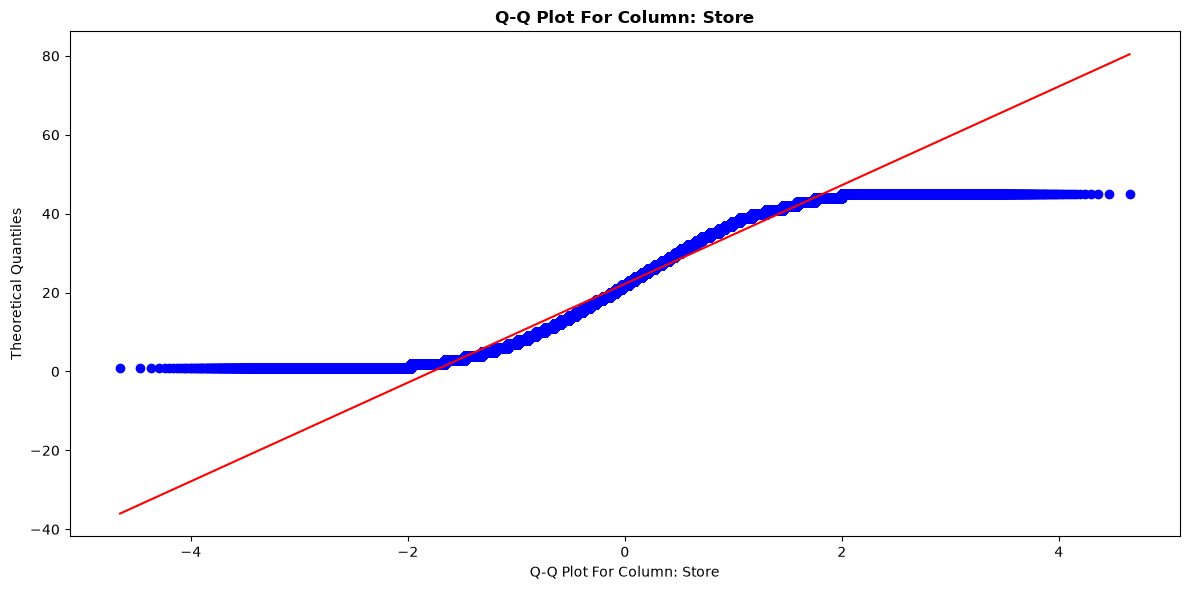



Q-Q Plot For Column: Dept


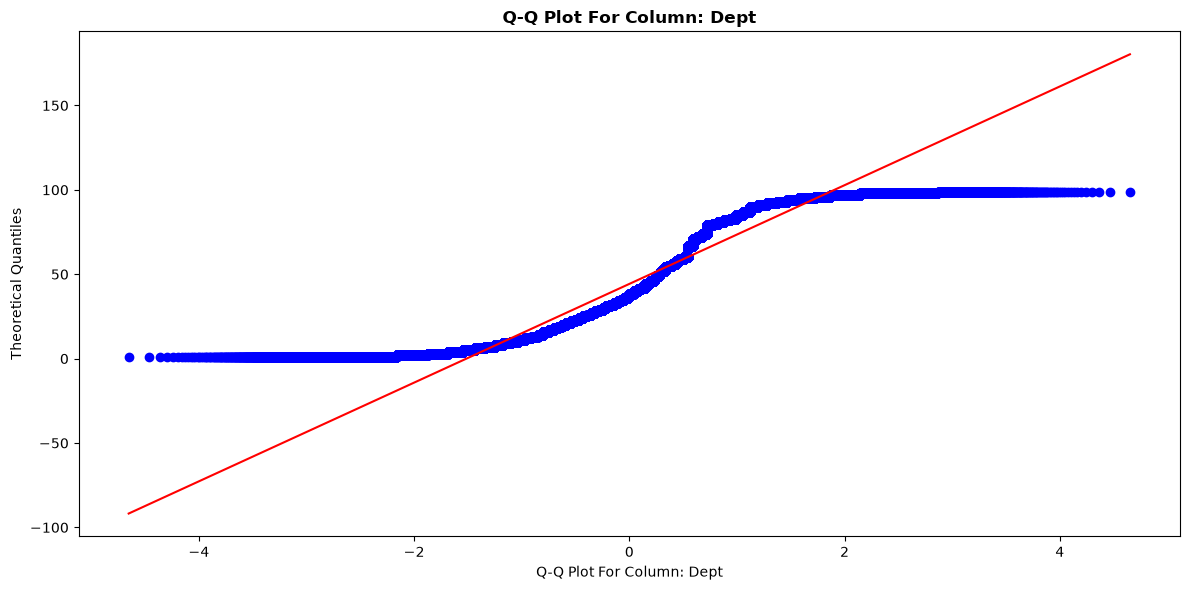



Q-Q Plot For Column: Weekly_Sales


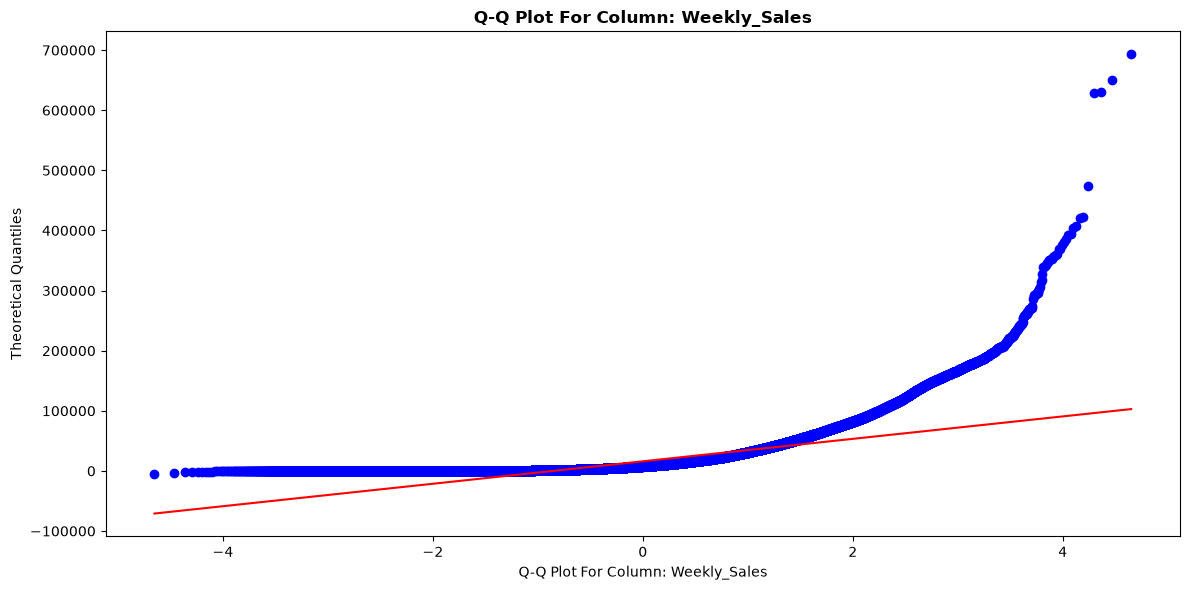



Q-Q Plot For Column: IsHoliday


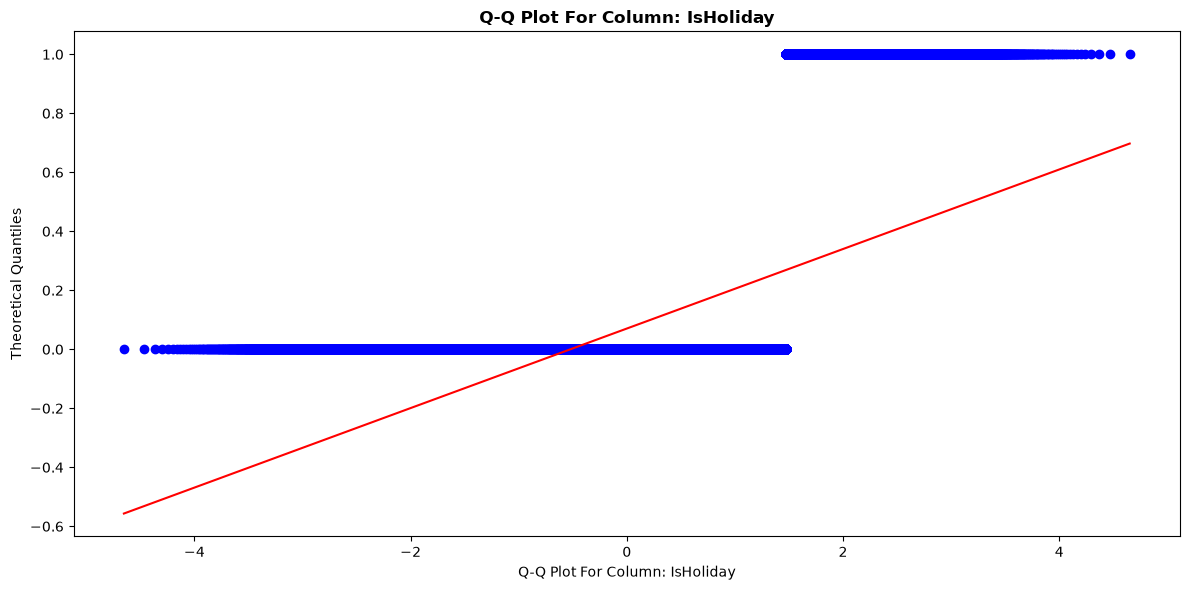



Q-Q Plot For Column: MarkDown1


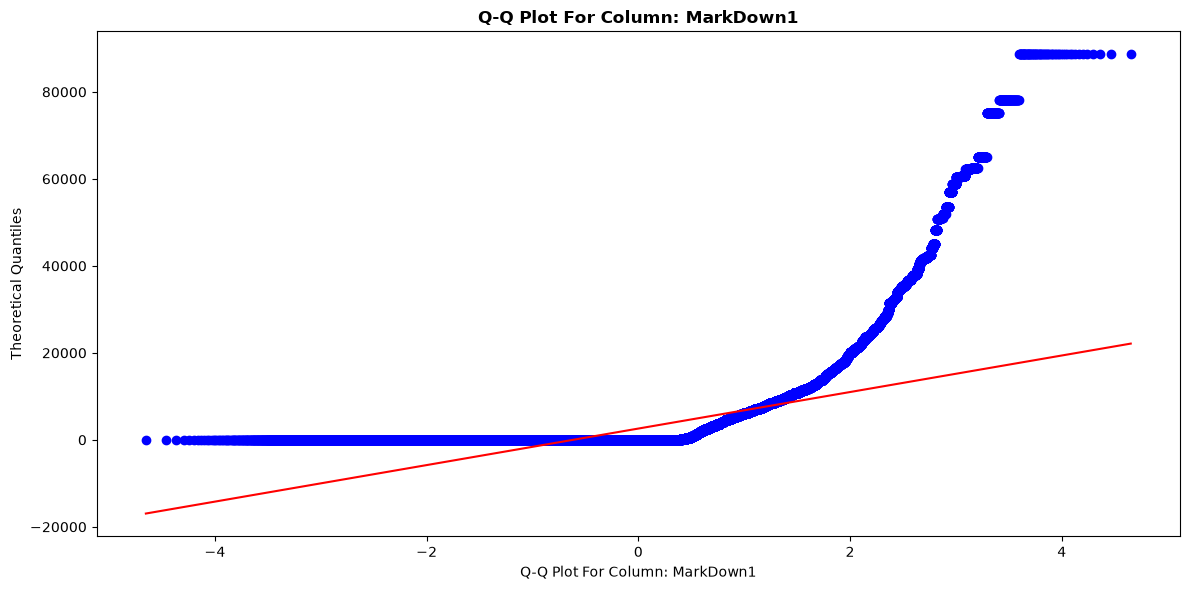



Q-Q Plot For Column: MarkDown2


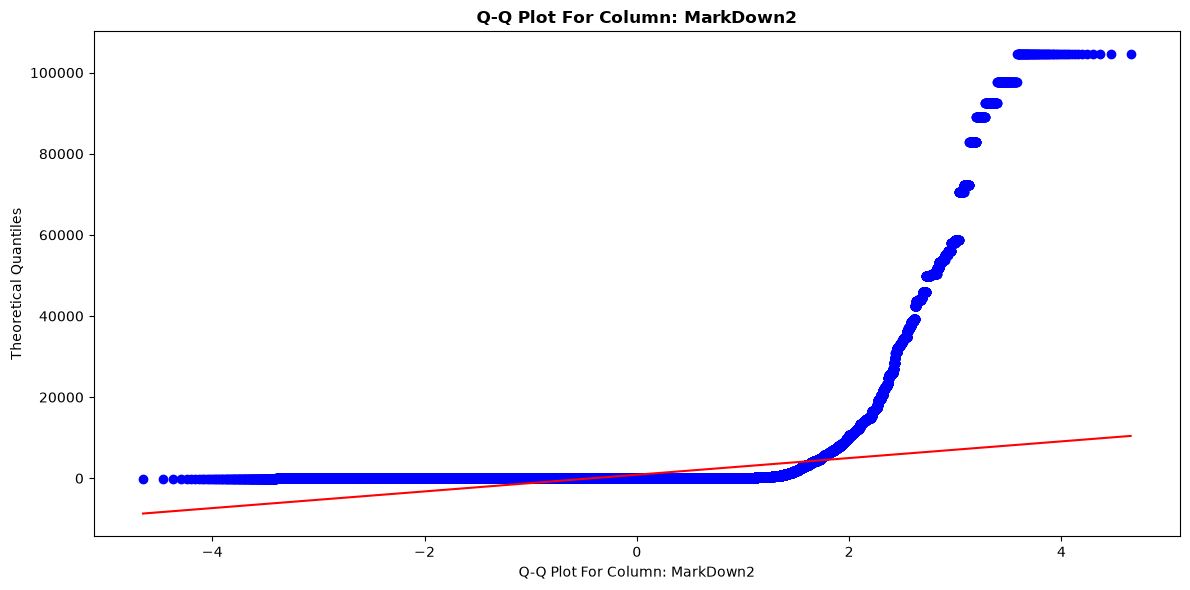



Q-Q Plot For Column: MarkDown3


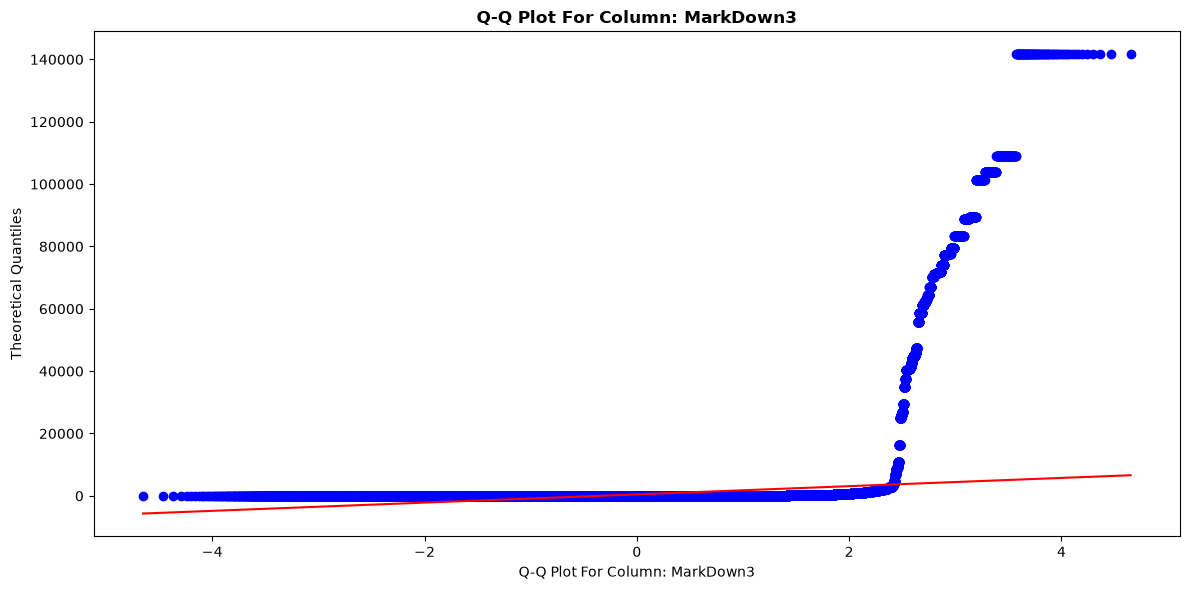



Q-Q Plot For Column: MarkDown4


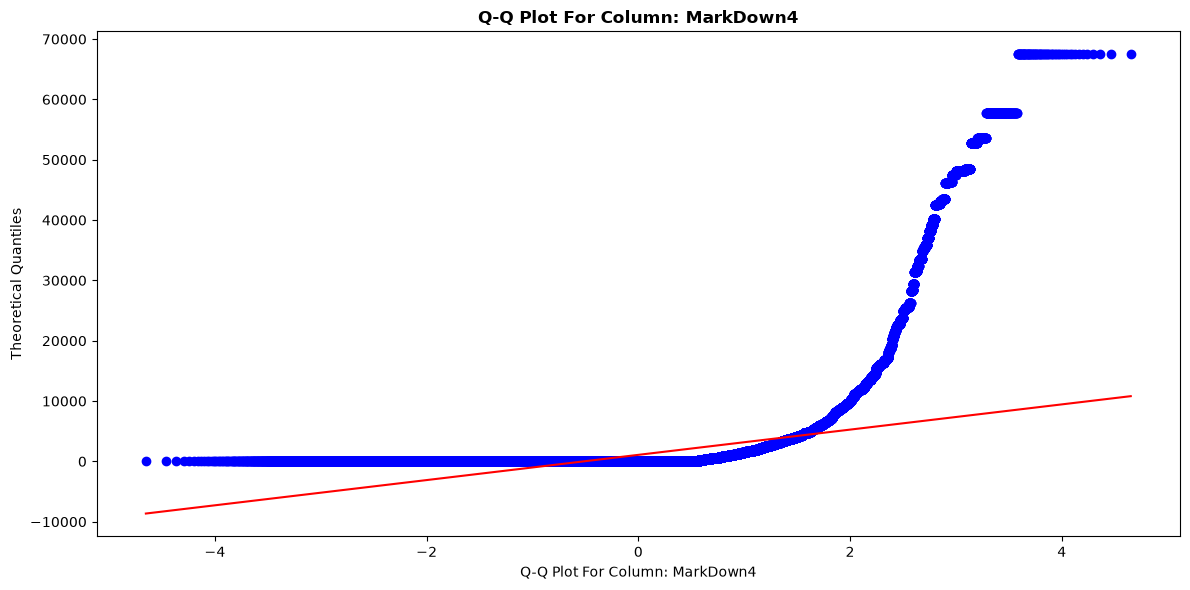



Q-Q Plot For Column: MarkDown5


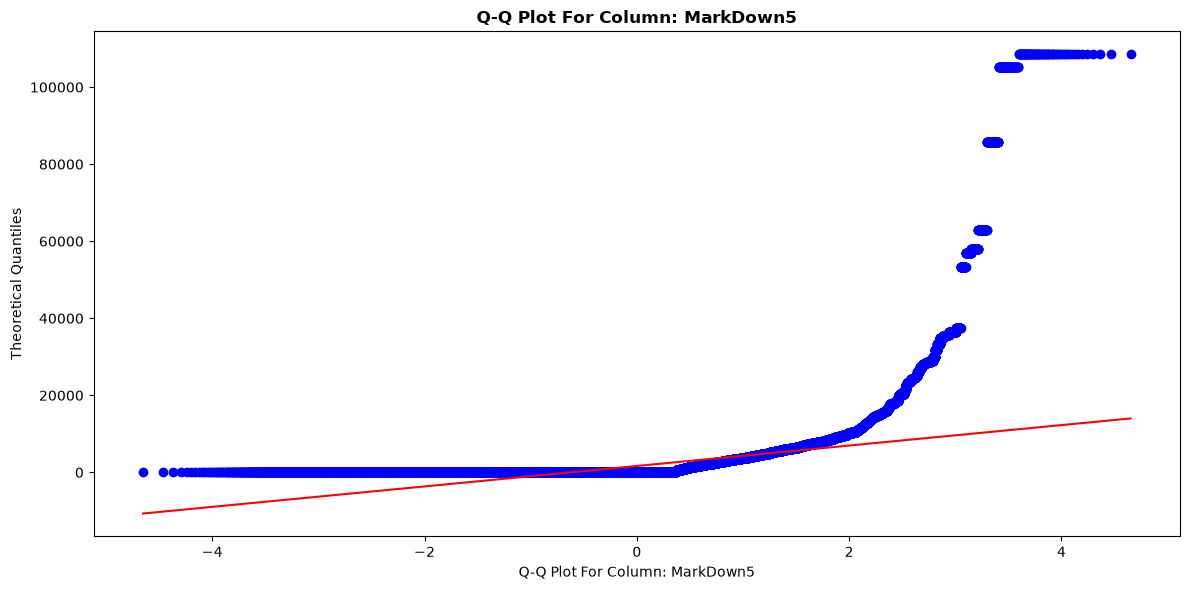



Q-Q Plot For Column: Store_Type


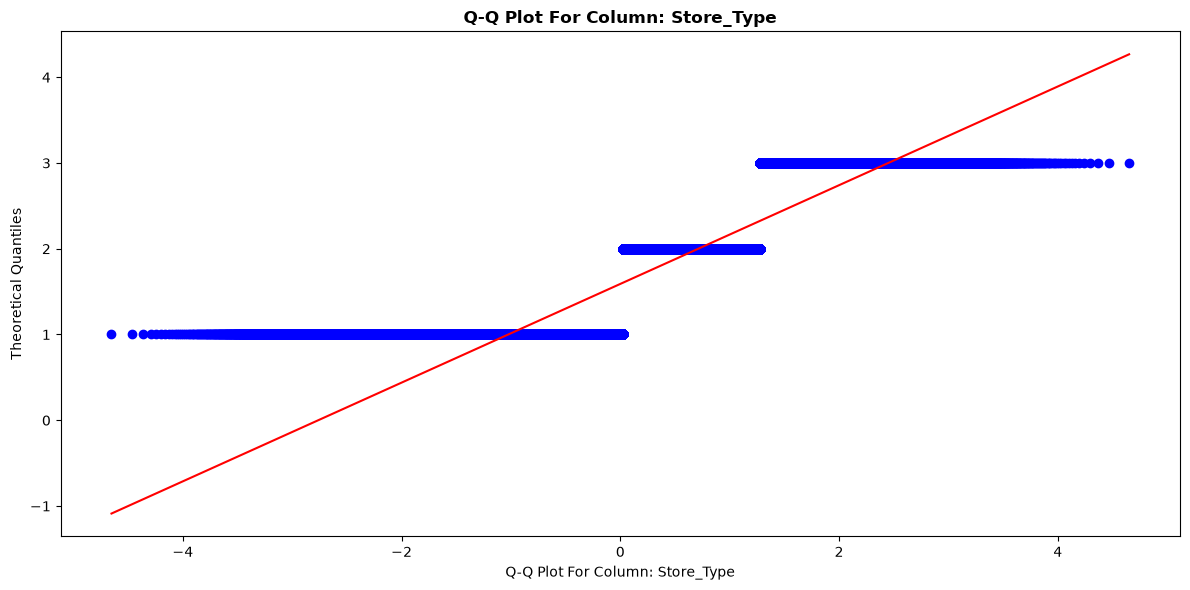



Q-Q Plot For Column: Store_Size


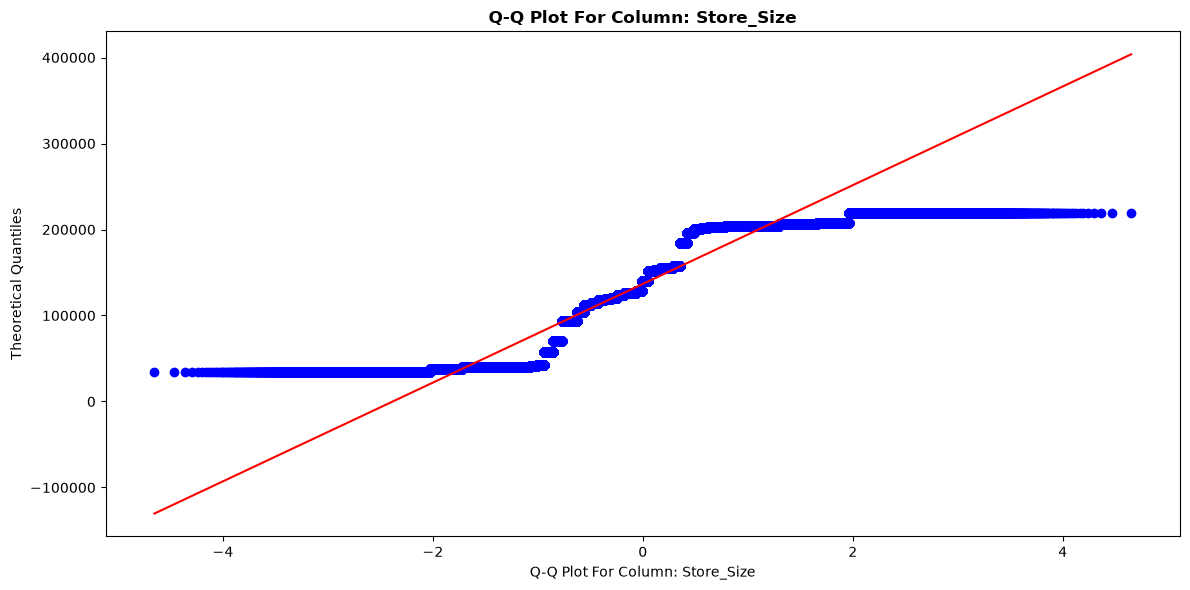



Q-Q Plot For Column: Temperature


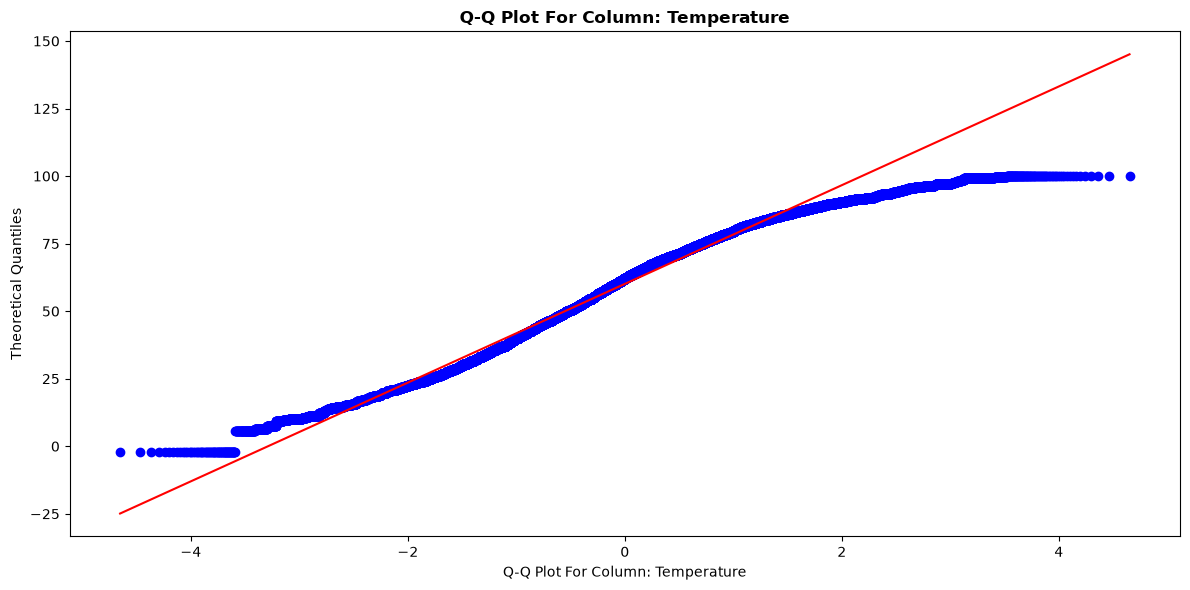



Q-Q Plot For Column: Unemployment


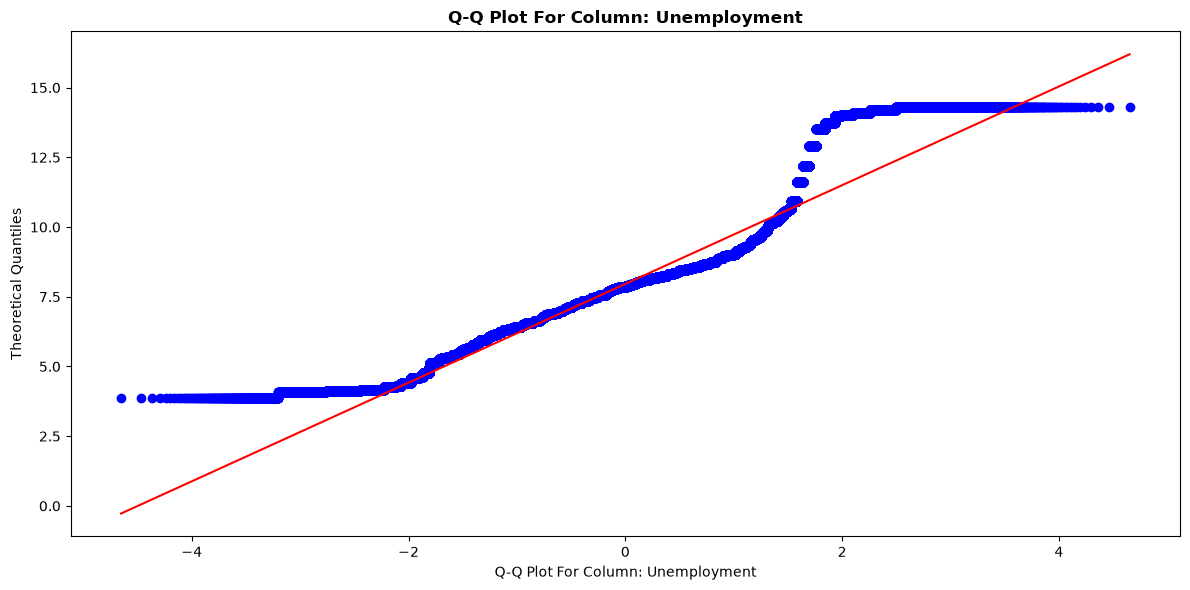



Q-Q Plot For Column: YearMonth


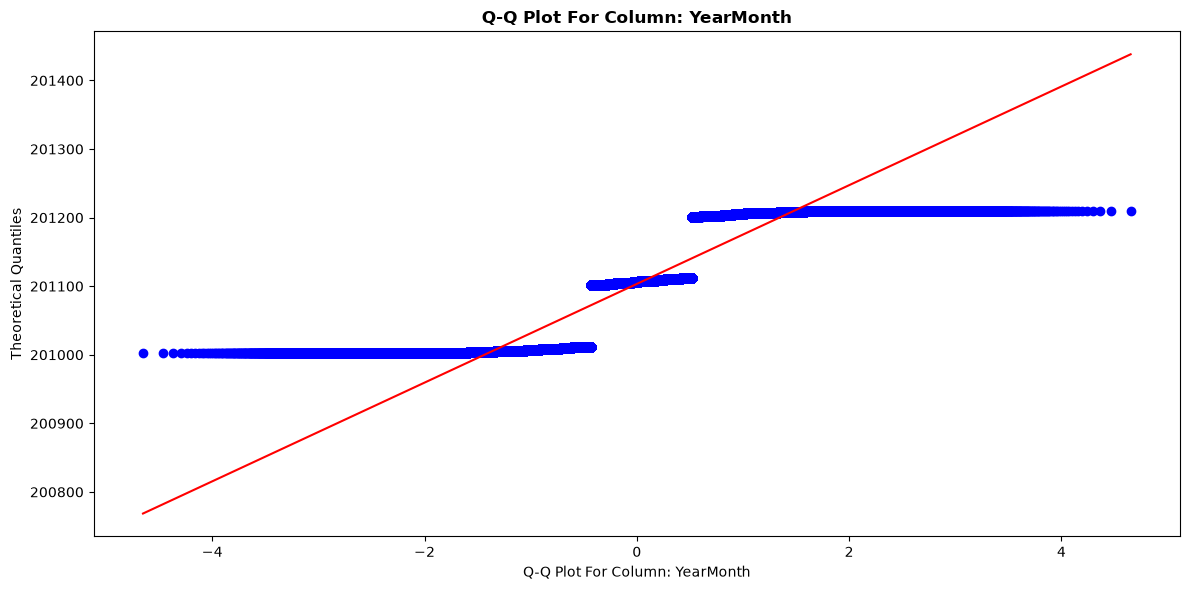

In [6]:
#get column skew

modETL.funcGetColumnSkew(dfSales_Combined_DataSet_Work)

# Observations: EDL - Sales Combined DataSet

The skew data shows some interesting results, and potential correlations

Unnamed column can be ignored as that is a pandas crated index, no harm in having a data file indexed will be ignored

Column By Column Analysis:

Store - ignoring this as has numeric effect on the data analysis hence the 0 skew!  
Dept - again ignoring this column  
Weekly_Sales - highly positively skewed, this is expected as the data is not normally distributed as it is sales value  
               could hypothesise that the highly positively skewed values are good for business!  
IsHoliday - ignored as provides no meaningful insight  
Markdown columns - interesting as start flatlined then exponentailly increase, could provide insights as might be   
                   correlated to sales as is by its nature cost of marketing schemes and promotions                 
Store_Type - ignored as provides no meaningful insight  
Store_Size - as above ignored  
Temperature - as above ignored  
Unemployment - highly positively skewed, could be interesting to see if this is correlated to sales....  
YearMonth - ignored as Feature Engineering for potential visualisation  


# Section 3 - Tests For Each Hypothesis

Here we perform these tests:

- Shapiro-Wilk Test
- Q-Q Plots
- Parametric Tests
- Non-Parametric Tests
- Skewness and Kurtosis
